In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

import time

In [2]:
PROJECT_ROOT = (
    Path.cwd()
    .parent
)

SRC_DIR = (
    PROJECT_ROOT
    / "src"
)

if str(PROJECT_ROOT) not in sys.path:

    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )

In [3]:
from src.data_pipeline import (
    list_ohlcv_files,
    load_ohlcv_data,
    analyse_ohlcv_data,
)

from src.supertrend_utils import (
    calculate_supertrend,
)

from src.strategy_engine import (
    generate_signals,
    backtest_strategy,
    calculate_performance,
)

from src.plotting_utils import (
    plot_ohlcv,
    plot_ohlcv_with_supertrend_bands,
    plot_ohlcv_with_supertrend,
    plot_strategy_trades,
    plot_cumulative_pnl,
    plot_performance_ratios,
    plot_strategy_performance,
)

In [4]:
ohlcv_filepaths = (
    list_ohlcv_files()
)

for ohlcv_filepath in (
    ohlcv_filepaths
):

    print(
        ohlcv_filepath.name
    )

XAUUSD_M1_2023.csv
XAUUSD_M1_2024.csv
XAUUSD_M1_2025.csv
XAUUSD_M1_2026.csv


In [5]:
ohlcv_data = (
    load_ohlcv_data(
        filepaths=ohlcv_filepaths
    )
)

In [6]:
ohlcv_data.head()

,open,high,low,close,tick_volume,source_file
time,,,,,,
2023-03-20 14:31:00,1980.86,1981.13,1980.46,1980.58,85,XAUUSD_M1_2023.csv
2023-03-20 14:32:00,1980.58,1980.75,1979.68,1980.68,97,XAUUSD_M1_2023.csv
2023-03-20 14:33:00,1980.68,1980.70,1979.55,1979.58,74,XAUUSD_M1_2023.csv
2023-03-20 14:34:00,1979.48,1979.90,1979.15,1979.62,98,XAUUSD_M1_2023.csv
2023-03-20 14:35:00,1979.62,1980.65,1979.58,1980.30,101,XAUUSD_M1_2023.csv


In [7]:
ohlcv_data.tail()

,open,high,low,close,tick_volume,source_file
time,,,,,,
2026-07-03 19:55:00,4175.19,4175.72,4174.82,4175.72,52,XAUUSD_M1_2026.csv
2026-07-03 19:56:00,4175.72,4176.46,4175.46,4176.46,76,XAUUSD_M1_2026.csv
2026-07-03 19:57:00,4176.46,4176.46,4173.79,4174.02,88,XAUUSD_M1_2026.csv
2026-07-03 19:58:00,4174.04,4175.60,4173.80,4175.60,108,XAUUSD_M1_2026.csv
2026-07-03 19:59:00,4175.63,4175.90,4174.89,4174.94,88,XAUUSD_M1_2026.csv


In [8]:
start_time = time.time()
supertrend_data = (
    calculate_supertrend(
        ohlcv_data=ohlcv_data,
        atr_period=10,
        multiplier=3.0,
    )
)
end_time = time.time()

supertrend_time = end_time - start_time
print(supertrend_time)

0.3211357593536377


In [9]:
supertrend_data.columns

Index(['open', 'high', 'low', 'close', 'tick_volume', 'source_file',
       'true_range', 'atr', 'basic_upper_band', 'basic_lower_band',
       'final_upper_band', 'final_lower_band', 'supertrend', 'trend'],
      dtype='str')

In [10]:
supertrend_data.head()

,open,high,low,close,tick_volume,source_file,true_range,atr,basic_upper_band,basic_lower_band,final_upper_band,final_lower_band,supertrend,trend
time,,,,,,,,,,,,,,
2023-03-20 14:31:00,1980.86,1981.13,1980.46,1980.58,85,XAUUSD_M1_2023.csv,0.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-20 14:32:00,1980.58,1980.75,1979.68,1980.68,97,XAUUSD_M1_2023.csv,1.07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-20 14:33:00,1980.68,1980.70,1979.55,1979.58,74,XAUUSD_M1_2023.csv,1.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-20 14:34:00,1979.48,1979.90,1979.15,1979.62,98,XAUUSD_M1_2023.csv,0.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-20 14:35:00,1979.62,1980.65,1979.58,1980.30,101,XAUUSD_M1_2023.csv,1.07,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
supertrend_data.tail()

,open,high,low,close,tick_volume,source_file,true_range,atr,basic_upper_band,basic_lower_band,final_upper_band,final_lower_band,supertrend,trend
time,,,,,,,,,,,,,,
2026-07-03 19:55:00,4175.19,4175.72,4174.82,4175.72,52,XAUUSD_M1_2026.csv,0.90,1.179494,4178.808482,4171.731518,4178.450162,4171.731518,4171.731518,1.0
2026-07-03 19:56:00,4175.72,4176.46,4175.46,4176.46,76,XAUUSD_M1_2026.csv,1.00,1.161544,4179.444633,4172.475367,4178.450162,4172.475367,4172.475367,1.0
2026-07-03 19:57:00,4176.46,4176.46,4173.79,4174.02,88,XAUUSD_M1_2026.csv,2.67,1.312390,4179.062170,4171.187830,4178.450162,4172.475367,4172.475367,1.0
2026-07-03 19:58:00,4174.04,4175.60,4173.80,4175.60,108,XAUUSD_M1_2026.csv,1.80,1.361151,4178.783453,4170.616547,4178.450162,4172.475367,4172.475367,1.0
2026-07-03 19:59:00,4175.63,4175.90,4174.89,4174.94,88,XAUUSD_M1_2026.csv,1.01,1.326036,4179.373108,4171.416892,4178.450162,4172.475367,4172.475367,1.0


In [12]:
start_time = time.time()

signal_data = (
    generate_signals(
        supertrend_data=supertrend_data
    )
)

end_time = time.time()
signal_time = end_time - start_time 

print(signal_time)

0.06028413772583008


In [13]:
signal_data[
    signal_data["long_signal"]
    |
    signal_data["short_signal"]
]

,open,high,low,close,tick_volume,source_file,true_range,atr,basic_upper_band,basic_lower_band,final_upper_band,final_lower_band,supertrend,trend,long_signal,short_signal
time,,,,,,,,,,,,,,,,
2023-03-20 14:56:00,1983.98,1984.20,1983.42,1983.58,116,XAUUSD_M1_2023.csv,0.78,0.810030,1986.240089,1981.379911,1984.104641,1981.379911,1984.104641,-1.0,False,True
2023-03-20 15:15:00,1982.08,1982.16,1981.10,1982.04,120,XAUUSD_M1_2023.csv,1.10,0.712877,1983.768631,1979.491369,1983.768631,1981.902467,1981.902467,1.0,True,False
2023-03-20 16:53:00,1981.25,1981.35,1979.47,1979.66,175,XAUUSD_M1_2023.csv,1.88,1.661550,1985.394649,1975.425351,1985.394649,1979.653638,1979.653638,1.0,True,False
2023-03-20 16:54:00,1979.66,1981.94,1979.33,1981.94,187,XAUUSD_M1_2023.csv,2.61,1.756395,1985.904184,1975.365816,1985.394649,1979.653638,1979.653638,1.0,True,False
2023-03-20 16:57:00,1980.26,1980.26,1979.36,1979.71,160,XAUUSD_M1_2023.csv,0.90,1.664172,1984.802515,1974.817485,1984.802515,1979.653638,1979.653638,1.0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-03 13:31:00,4177.99,4179.04,4177.79,4179.04,94,XAUUSD_M1_2026.csv,1.25,1.101068,4181.718203,4175.111797,4181.593559,4177.861689,4177.861689,1.0,True,False
2026-07-03 15:12:00,4180.27,4180.86,4178.58,4179.03,144,XAUUSD_M1_2026.csv,2.28,1.423813,4183.991439,4175.448561,4183.991439,4178.598904,4178.598904,1.0,True,False
2026-07-03 17:15:00,4162.21,4164.57,4162.21,4164.04,150,XAUUSD_M1_2026.csv,2.36,2.272621,4170.207862,4156.572138,4164.403054,4156.930057,4164.403054,-1.0,False,True


In [14]:
start_time = time.time()

trades_data = (
    backtest_strategy(
        signal_data=signal_data,
        reward_risk=2.0,
        same_bar_priority="stop",
    )
)

end_time = time.time()

trades_time = end_time - start_time
print(trades_time)

0.1361551284790039


In [15]:
trades_data.head()

,direction,entry_time,entry_index,entry_price,stop_loss,take_profit,risk,exit_time,exit_index,exit_price,exit_reason,pnl,r_multiple
0,short,2023-03-20 14:57:00,26,1983.58,1984.20,1982.34,0.62,2023-03-20 15:00:00,29,1984.20,stop_loss,-0.62,-1.0
1,long,2023-03-20 15:16:00,45,1982.16,1981.10,1984.28,1.06,2023-03-20 15:16:00,45,1984.28,take_profit,2.12,2.0
2,long,2023-03-20 16:54:00,143,1979.66,1979.47,1980.04,0.19,2023-03-20 16:54:00,143,1979.47,stop_loss,-0.19,-1.0
3,long,2023-03-20 16:58:00,147,1979.70,1979.36,1980.38,0.34,2023-03-20 16:58:00,147,1979.36,stop_loss,-0.34,-1.0
4,long,2023-03-20 17:29:00,178,1968.52,1968.36,1968.84,0.16,2023-03-20 17:29:00,178,1968.36,stop_loss,-0.16,-1.0


In [16]:
trades_data.tail()

,direction,entry_time,entry_index,entry_price,stop_loss,take_profit,risk,exit_time,exit_index,exit_price,exit_reason,pnl,r_multiple
19389,long,2026-07-03 13:01:00,1165394,4173.14,4170.80,4177.82,2.34,2026-07-03 13:08:00,1165401,4177.82,take_profit,4.68,2.0
19390,long,2026-07-03 13:31:00,1165424,4177.99,4177.72,4178.53,0.27,2026-07-03 13:31:00,1165424,4178.53,take_profit,0.54,2.0
19391,long,2026-07-03 15:13:00,1165526,4179.03,4178.58,4179.93,0.45,2026-07-03 15:13:00,1165526,4179.93,take_profit,0.90,2.0
19392,short,2026-07-03 17:16:00,1165649,4163.92,4164.57,4162.62,0.65,2026-07-03 17:17:00,1165650,4164.57,stop_loss,-0.65,-1.0
19393,long,2026-07-03 18:21:00,1165714,4170.09,4169.29,4171.69,0.80,2026-07-03 18:25:00,1165718,4169.29,stop_loss,-0.80,-1.0


In [18]:
performance_metrics = (
    calculate_performance(
        trades_data=trades_data
    )
)

In [19]:
ohlcv_window = ohlcv_data.iloc[:2000].copy()
supertrend_window = supertrend_data.iloc[:2000].copy()
signal_window = signal_data.iloc[:2000].copy()
trades_window = trades_data.iloc[:2000].copy()
#metrics_window = calculate_performance(trades_data=trades_window)

/opt/miniconda3/envs/quant_env/lib/python3.11/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


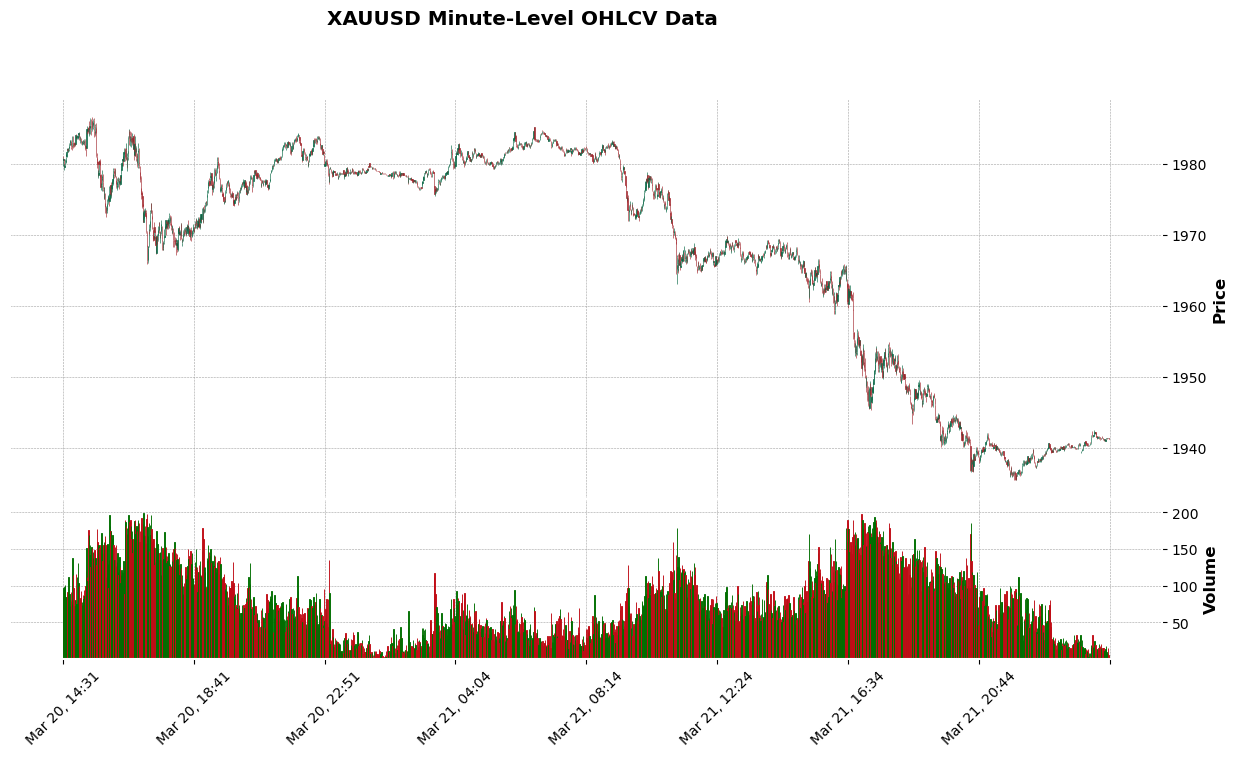

In [20]:
plot_ohlcv(
    ohlcv_data=ohlcv_window,
    title="XAUUSD Minute-Level OHLCV Data",
)

/opt/miniconda3/envs/quant_env/lib/python3.11/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


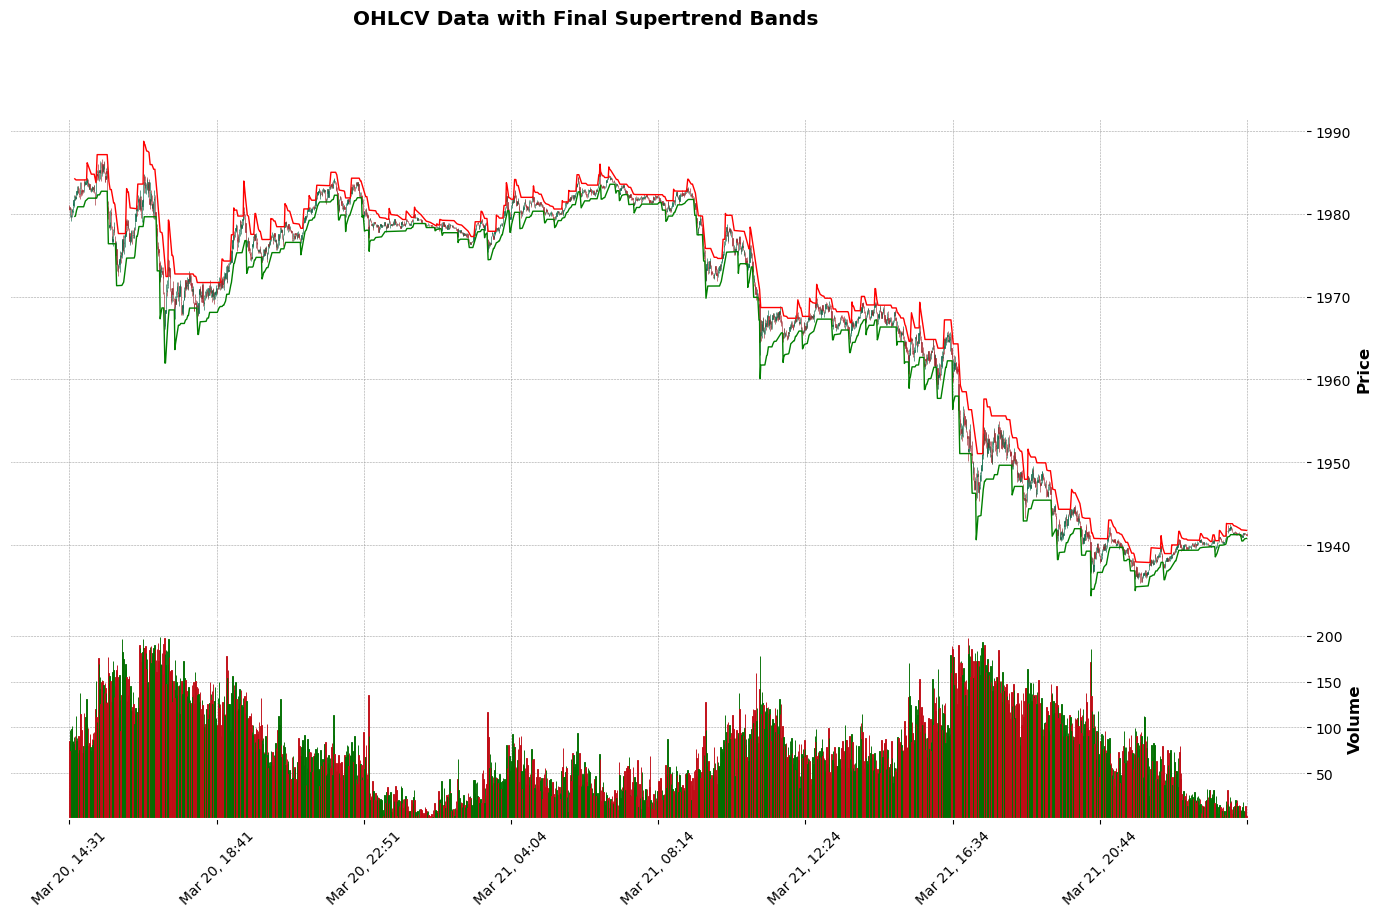

In [21]:
plot_ohlcv_with_supertrend_bands(
    supertrend_data=supertrend_window,
)

/opt/miniconda3/envs/quant_env/lib/python3.11/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


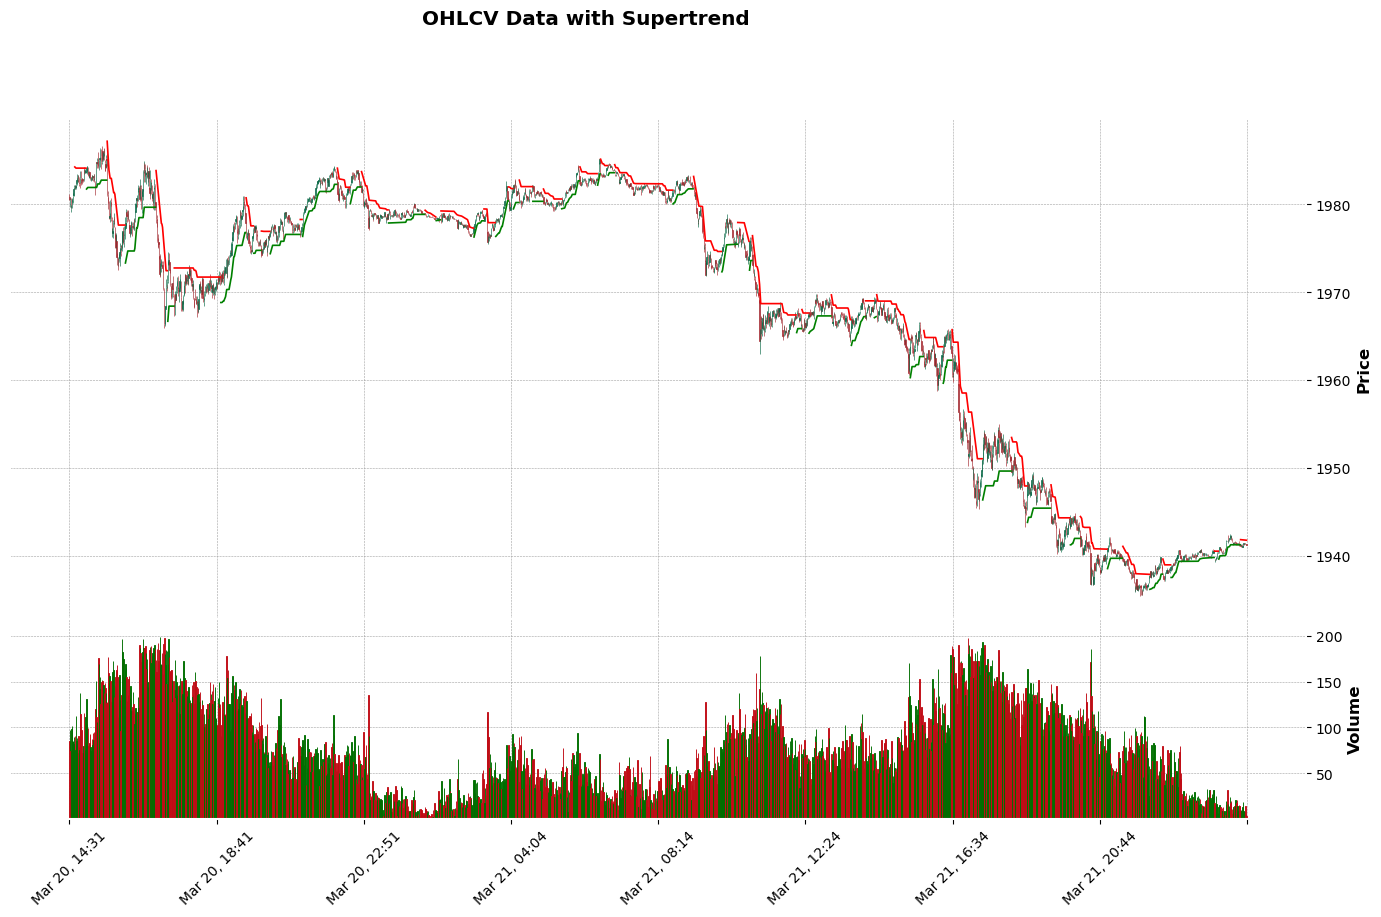

In [22]:
plot_ohlcv_with_supertrend(
    supertrend_data=supertrend_window,
)

/opt/miniconda3/envs/quant_env/lib/python3.11/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


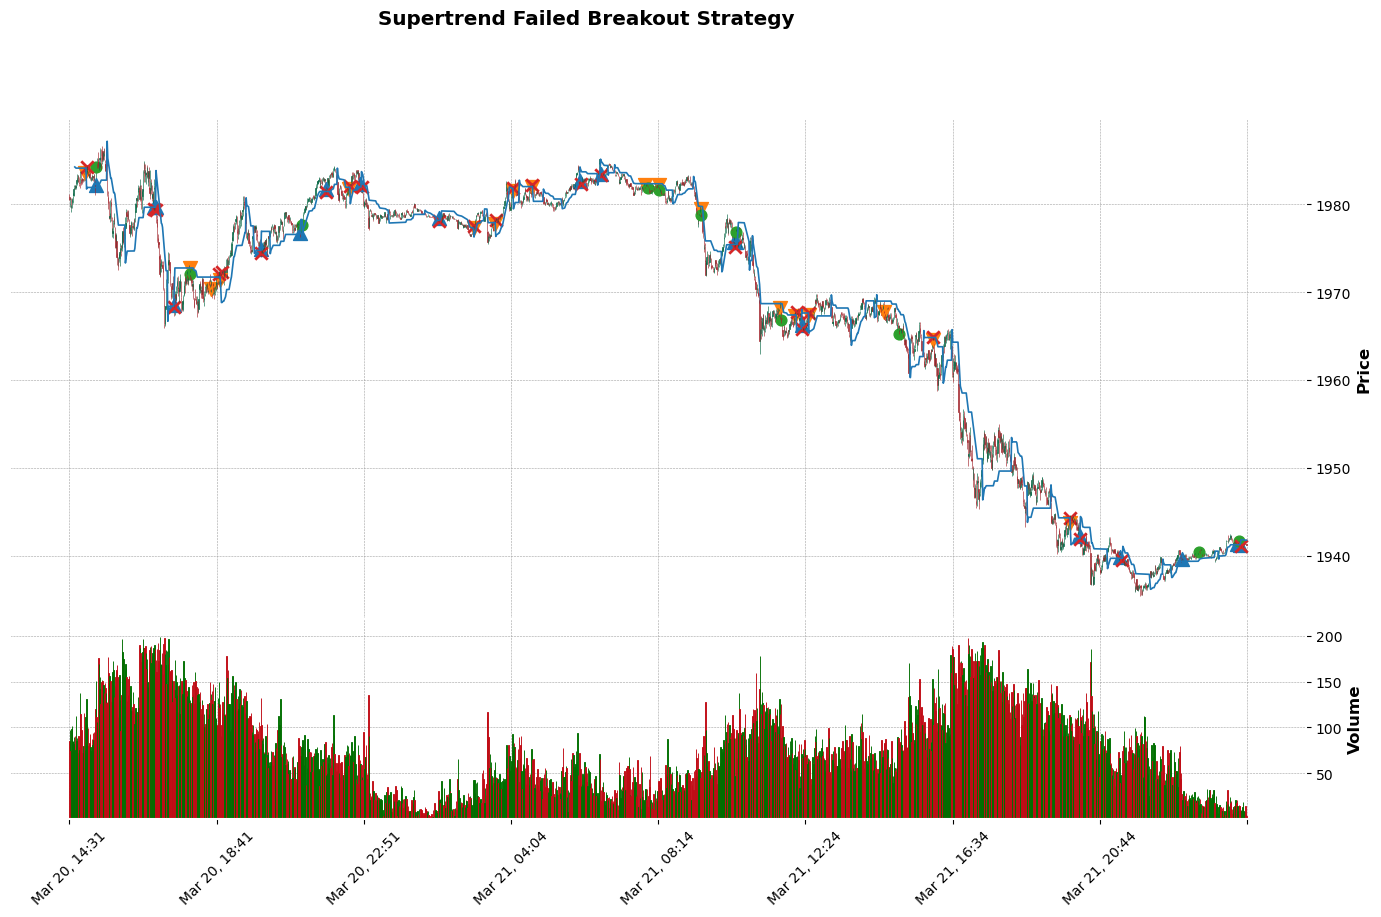

In [23]:
plot_strategy_trades(
    signal_data=signal_window,
    trades_data=trades_window,
)

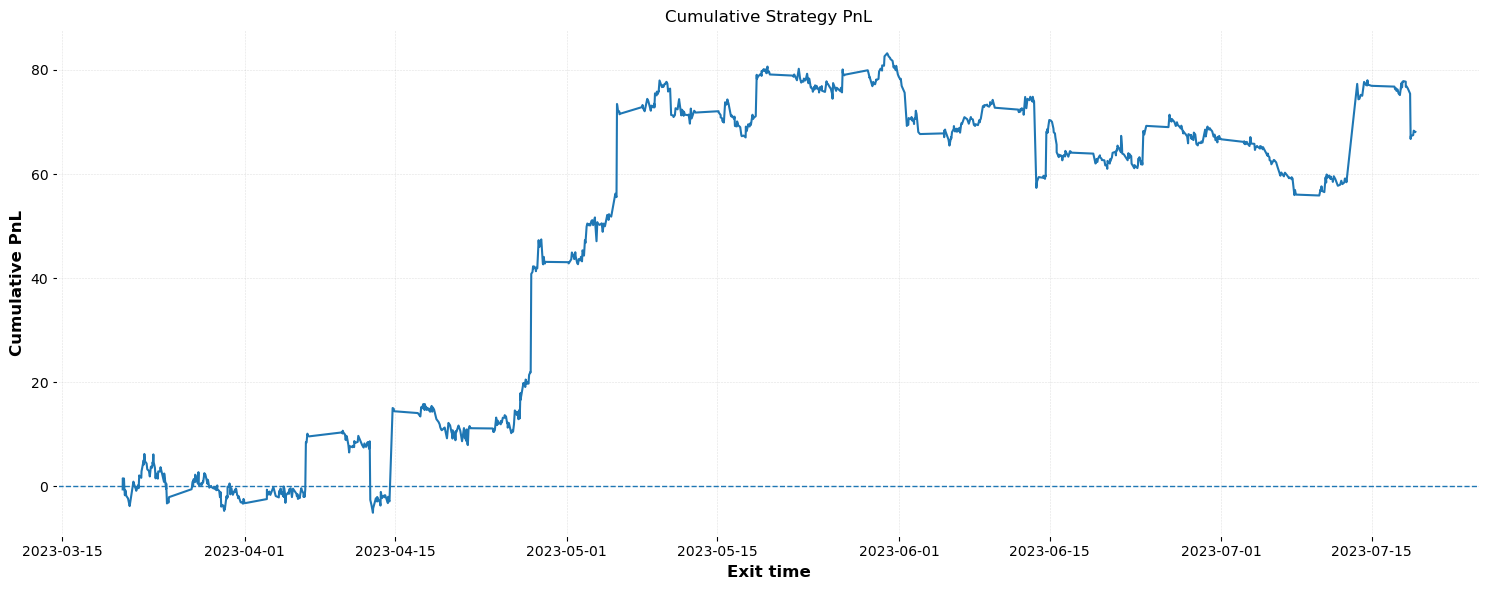

In [24]:
plot_cumulative_pnl(
    trades_data=trades_window
)

In [25]:
plot_performance_ratios(
    performance_metrics=performance_metrics
)

TypeError: unhashable type: 'dict'

In [26]:
plot_strategy_performance(
    trades_data=trades_data,
    performance_metrics=performance_metrics,
)

TypeError: unhashable type: 'dict'

In [27]:
print(performance_metrics)

({'total_trades': 19394, 'win_rate': 0.3244817984943797, 'profit_factor': np.float64(1.0351724910702573), 'average_r_multiple': np.float64(-0.026554604516860904), 'total_pnl': np.float64(357.8400000000495), 'total_return_percent': np.float64(0.0035784000000005367), 'annualized_return_percent': np.float64(0.00104723077223845), 'maximum_drawdown_absolute': np.float64(272.6900000000023), 'maximum_drawdown_percent': np.float64(0.002715138833116611), 'annualized_sharpe_ratio': np.float64(0.5950399455758155), 'annualized_sortino_ratio': np.float64(0.7821639735206198), 'calmar_ratio': np.float64(0.38570063507079344)},      exit_time     equity  cumulative_pnl  drawdown_absolute  drawdown_percent
0   2023-03-20   99998.19           -1.81               0.00          0.000000
1   2023-03-21   99999.89           -0.11               0.00          0.000000
2   2023-03-22  100003.25            3.25               0.00          0.000000
3   2023-03-23  100002.84            2.84              -0.41     

In [34]:
print(
    "Total PnL:",
    trades_data["pnl"].sum()
)

print(
    "Mean PnL:",
    trades_data["pnl"].mean()
)

print(
    "Mean R:",
    trades_data["r_multiple"].mean()
)

print(
    "Std R:",
    trades_data["r_multiple"].std()
)

print(
    "Total R:",
    trades_data["r_multiple"].sum()
)

Total PnL: 290.1900000000353
Mean PnL: 0.014950540958270753
Mean R: -0.02349304482225654
Std R: 1.4057228881060606
Total R: -455.99999999999943


In [35]:
equity_curve = (
    trades_data["r_multiple"]
    .cumsum()
)

drawdown = (
    equity_curve
    -
    equity_curve.cummax()
)

print(
    "Final equity:",
    equity_curve.iloc[-1]
)

print(
    "Maximum drawdown:",
    drawdown.min()
)

Final equity: -455.99999999999943
Maximum drawdown: -582.9999999999994
